<a href="https://colab.research.google.com/github/sadichyaa/Assesment1/blob/main/2436299_SadikshyaNepal_final_assestment_part3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sarcastic Headline Classification Using RNN, LSTM, and Pretrained Word Embeddings

This project focuses on binary text classification using a sarcastic headline dataset. The aim is to classify whether a news headline is sarcastic or not sarcastic using deep learning models such as Simple RNN, LSTM, and LSTM with pretrained word embeddings.

In [1]:
!pip install contractions
!pip install nltk
!pip install wordcloud
!pip install gensim
!pip install gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 54.2 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import re
import time
import matplotlib.pyplot as plt
import seaborn as sns
import contractions
import nltk
import gensim.downloader as api
import gradio as gr

from wordcloud import WordCloud
from collections import Counter

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

In [ ]:
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
DATASET_PATH = "/content/drive/MyDrive/AI-ML Assignment /Data/8. Sarcastic or Not Sarcastic Dataset/sarcastic_headlines.csv"

df = pd.read_csv(DATASET_PATH)

df.head()

,headline,is_sarcastic
0,thirtysomething scientists unveil doomsday clo...,1
1,dem rep. totally nails why congress is falling...,0
2,eat your veggies: 9 deliciously different recipes,0
3,inclement weather prevents liar from getting t...,1
4,mother comes pretty close to using word 'strea...,1


In [ ]:
print(df.columns)
print(df.shape)
df.info()

Index(['headline', 'is_sarcastic'], dtype='object')
(28619, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28619 entries, 0 to 28618
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   headline      28619 non-null  object
 1   is_sarcastic  28619 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 447.3+ KB


In [ ]:
df = df[["headline", "is_sarcastic"]]
df.head()

,headline,is_sarcastic
0,thirtysomething scientists unveil doomsday clo...,1
1,dem rep. totally nails why congress is falling...,0
2,eat your veggies: 9 deliciously different recipes,0
3,inclement weather prevents liar from getting t...,1
4,mother comes pretty close to using word 'strea...,1


In [ ]:
print("Total records:", len(df))
print(df["is_sarcastic"].value_counts())

Total records: 28619
is_sarcastic
0    14985
1    13634
Name: count, dtype: int64


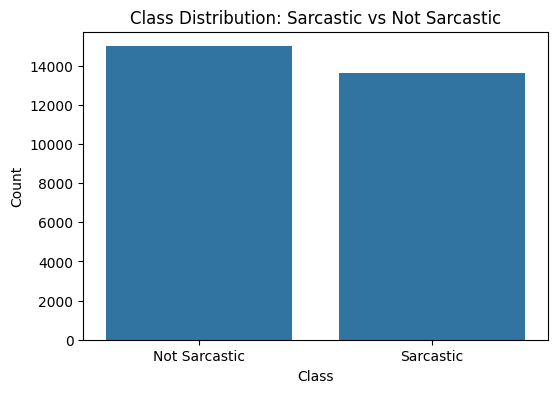

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x="is_sarcastic", data=df)
plt.title("Class Distribution: Sarcastic vs Not Sarcastic")
plt.xlabel("Class")
plt.ylabel("Count")
plt.xticks([0,1], ["Not Sarcastic", "Sarcastic"])
plt.show()

The dataset used in this project is a sarcastic headline classification dataset. It contains news headlines labelled as sarcastic or not sarcastic. The task is a binary text classification problem where the model learns linguistic patterns from headlines and predicts whether a new headline is sarcastic.

In [ ]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = str(text).lower()

    # Expand contractions: don't -> do not
    text = contractions.fix(text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # Remove mentions and hashtags
    text = re.sub(r"@\w+|#\w+", "", text)

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove special characters and punctuation
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # Remove extra spaces
    text = re.sub(r"\s+", " ", text).strip()

    # Tokenize manually
    words = text.split()

    # Remove stopwords and lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [ ]:
df["clean_headline"] = df["headline"].apply(clean_text)

df[["headline", "clean_headline", "is_sarcastic"]].head()

,headline,clean_headline,is_sarcastic
0,thirtysomething scientists unveil doomsday clo...,thirtysomething scientist unveil doomsday cloc...,1
1,dem rep. totally nails why congress is falling...,dem rep totally nail congress falling short ge...,0
2,eat your veggies: 9 deliciously different recipes,eat veggie deliciously different recipe,0
3,inclement weather prevents liar from getting t...,inclement weather prevents liar getting work,1
4,mother comes pretty close to using word 'strea...,mother come pretty close using word streaming ...,1


In [ ]:
print(df.isnull().sum())

df = df.dropna()
df = df[df["clean_headline"].str.strip() != ""]

print("Dataset after cleaning:", df.shape)

headline          0
is_sarcastic      0
clean_headline    0
dtype: int64
Dataset after cleaning: (28617, 3)


In [ ]:
all_words = " ".join(df["clean_headline"]).split()
word_freq = Counter(all_words)

common_words = word_freq.most_common(20)
common_words_df = pd.DataFrame(common_words, columns=["Word", "Frequency"])

common_words_df

,Word,Frequency
0,trump,1794
1,new,1677
2,man,1507
3,woman,884
4,say,709
5,report,691
6,get,637
7,day,589
8,one,579
9,year,558


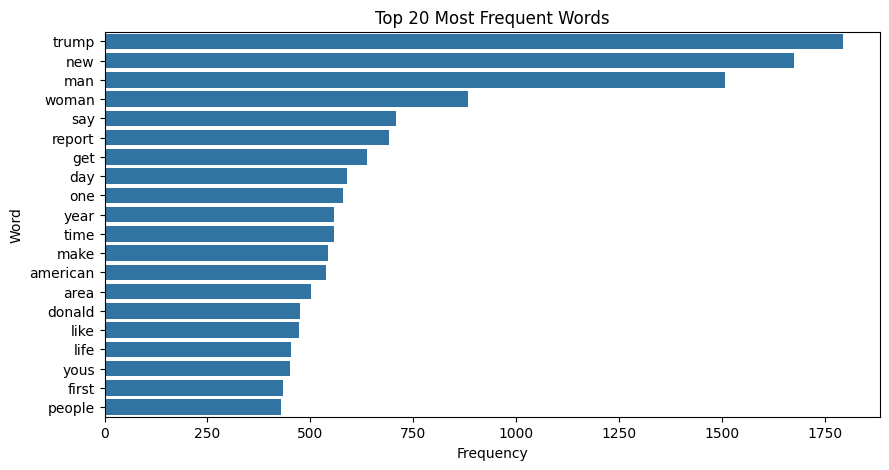

In [ ]:
plt.figure(figsize=(10,5))
sns.barplot(x="Frequency", y="Word", data=common_words_df)
plt.title("Top 20 Most Frequent Words")
plt.show()

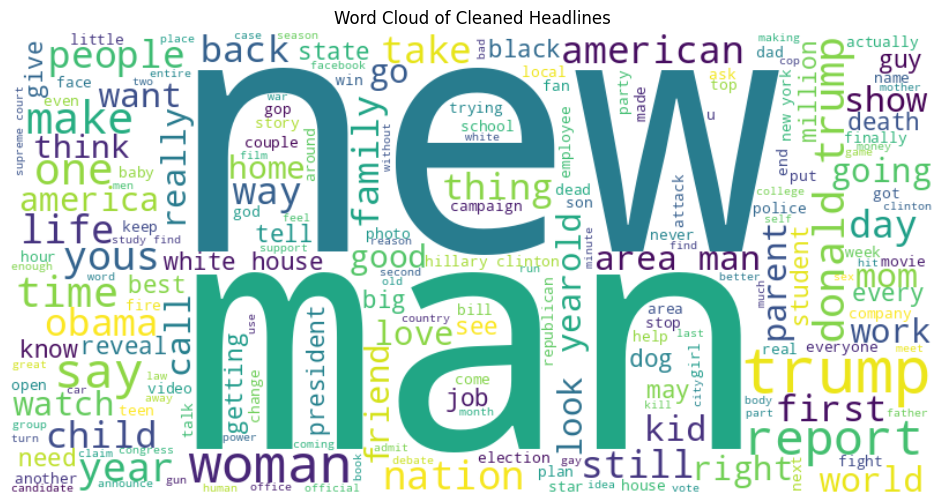

In [ ]:
text_data = " ".join(df["clean_headline"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(text_data)

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud of Cleaned Headlines")
plt.show()

In [ ]:
X = df["clean_headline"]
y = df["is_sarcastic"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 22893
Testing samples: 5724


In [ ]:
VOCAB_SIZE = 10000
OOV_TOKEN = "<OOV>"

tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token=OOV_TOKEN
)

tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

word_index = tokenizer.word_index

print("Vocabulary size:", len(word_index))

Vocabulary size: 22505


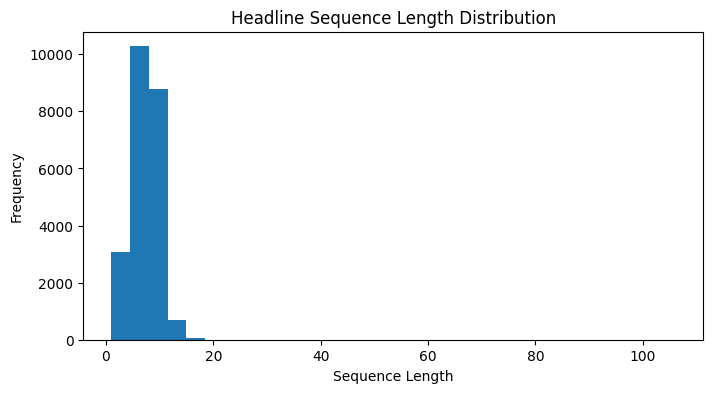

95th percentile max length: 11


In [ ]:
sequence_lengths = [len(seq) for seq in X_train_seq]

plt.figure(figsize=(8,4))
plt.hist(sequence_lengths, bins=30)
plt.title("Headline Sequence Length Distribution")
plt.xlabel("Sequence Length")
plt.ylabel("Frequency")
plt.show()

MAX_LEN = int(np.percentile(sequence_lengths, 95))
print("95th percentile max length:", MAX_LEN)

In [ ]:
X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

y_train = np.array(y_train)
y_test = np.array(y_test)

print(X_train_pad.shape)
print(X_test_pad.shape)

(22893, 11)
(5724, 11)


The cleaned headlines were converted into numerical sequences using Keras Tokenizer. A vocabulary size of 10,000 was selected to keep the most frequent words. Since neural networks require fixed-length inputs, padding was applied. Instead of using the maximum headline length, the 95th percentile sequence length was used to avoid unnecessarily long padded sequences.

In [ ]:
def plot_training_history(history, title):
    plt.figure(figsize=(7,5))
    plt.plot(history.history["accuracy"], label="Training Accuracy")
    plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
    plt.title(title + " Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()

    plt.figure(figsize=(7,5))
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(title + " Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

In [ ]:
def evaluate_model(model, X_test_pad, y_test, model_name):
    y_pred_prob = model.predict(X_test_pad)
    y_pred = (y_pred_prob > 0.5).astype("int32").flatten()

    acc = accuracy_score(y_test, y_pred)

    print(model_name, "Accuracy:", acc)
    print("\nClassification Report:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=["Not Sarcastic", "Sarcastic"]
    ))

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        xticklabels=["Not Sarcastic", "Sarcastic"],
        yticklabels=["Not Sarcastic", "Sarcastic"]
    )
    plt.title(model_name + " Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

    return acc

In [ ]:
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

In [ ]:
EMBEDDING_DIM = 64

rnn_model = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_LEN
    ),

    SimpleRNN(64),

    Dropout(0.4),

    Dense(32, activation="relu"),

    Dense(1, activation="sigmoid")
])

rnn_model.compile(
    loss="binary_crossentropy",
    optimizer=Adam(learning_rate=0.001),
    metrics=["accuracy"]
)

rnn_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

The first model used a Simple RNN with a trainable embedding layer. The embedding layer converted each word into a dense vector representation. The Simple RNN processed the headline as a sequence of words and passed the learned representation to dense layers for binary classification.

In [ ]:
start_time = time.time()

history_rnn = rnn_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

rnn_training_time = time.time() - start_time
print("RNN Training Time:", rnn_training_time, "seconds")

Epoch 1/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.7392 - loss: 0.5157 - val_accuracy: 0.7845 - val_loss: 0.4526
Epoch 2/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.8982 - loss: 0.2547 - val_accuracy: 0.7860 - val_loss: 0.4671
Epoch 3/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.9606 - loss: 0.1082 - val_accuracy: 0.7807 - val_loss: 0.6384
Epoch 4/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9800 - loss: 0.0545 - val_accuracy: 0.7792 - val_loss: 0.8296
RNN Training Time: 34.43201184272766 seconds


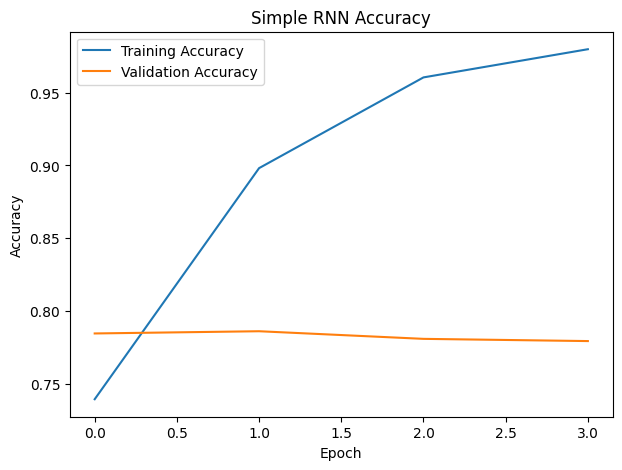

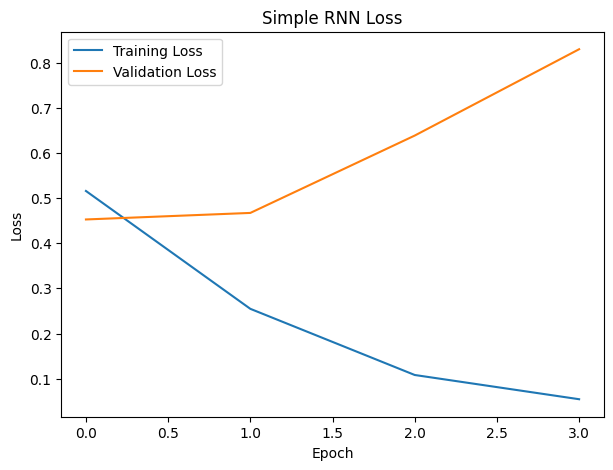

In [ ]:
plot_training_history(history_rnn, "Simple RNN")

179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Simple RNN Accuracy: 0.7803983228511531

Classification Report:
               precision    recall  f1-score   support

Not Sarcastic       0.74      0.91      0.81      2997
    Sarcastic       0.86      0.64      0.74      2727

     accuracy                           0.78      5724
    macro avg       0.80      0.77      0.77      5724
 weighted avg       0.80      0.78      0.78      5724



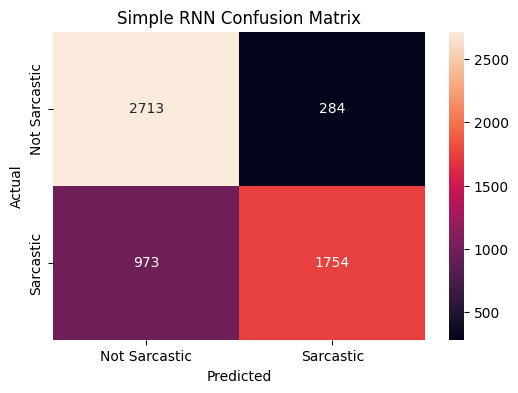

In [ ]:
rnn_acc = evaluate_model(rnn_model, X_test_pad, y_test, "Simple RNN")

In [ ]:
lstm_model = Sequential([
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=EMBEDDING_DIM,
        input_length=MAX_LEN
    ),

    LSTM(64),

    Dropout(0.4),

    Dense(32, activation="relu"),

    Dense(1, activation="sigmoid")
])

lstm_model.compile(
    loss="binary_crossentropy",
    optimizer=Adam(learning_rate=0.001),
    metrics=["accuracy"]
)

lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

The second model used an LSTM layer instead of a Simple RNN. LSTM networks are designed to handle sequential data more effectively because they use gates to control the flow of information. This helps reduce the vanishing gradient problem and allows the model to retain useful context from the headline.

In [ ]:
start_time = time.time()

history_lstm = lstm_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

lstm_training_time = time.time() - start_time
print("LSTM Training Time:", lstm_training_time, "seconds")

Epoch 1/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step - accuracy: 0.7472 - loss: 0.5019 - val_accuracy: 0.7827 - val_loss: 0.4603
Epoch 2/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.8645 - loss: 0.3169 - val_accuracy: 0.7945 - val_loss: 0.4790
Epoch 3/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - accuracy: 0.8993 - loss: 0.2390 - val_accuracy: 0.7978 - val_loss: 0.4763
LSTM Training Time: 30.63187289237976 seconds


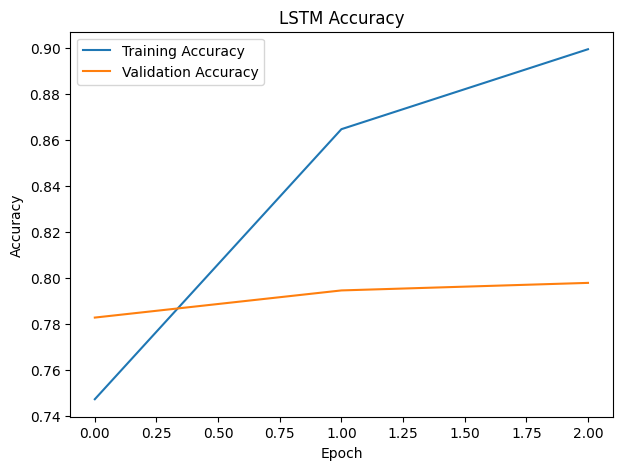

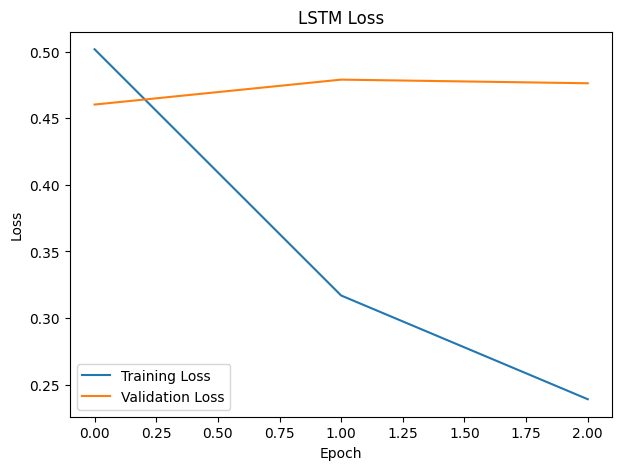

In [ ]:
plot_training_history(history_lstm, "LSTM")

179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
LSTM Accuracy: 0.7872117400419287

Classification Report:
               precision    recall  f1-score   support

Not Sarcastic       0.83      0.75      0.79      2997
    Sarcastic       0.75      0.83      0.79      2727

     accuracy                           0.79      5724
    macro avg       0.79      0.79      0.79      5724
 weighted avg       0.79      0.79      0.79      5724



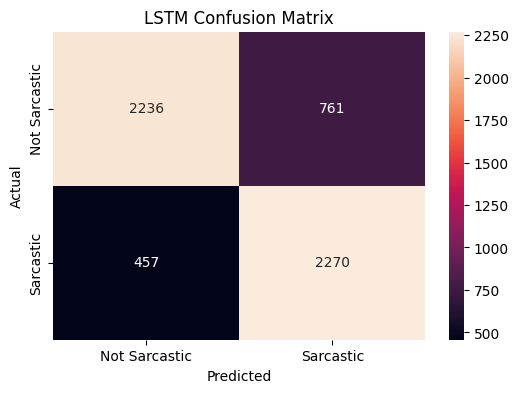

In [ ]:
lstm_acc = evaluate_model(lstm_model, X_test_pad, y_test, "LSTM")

In [ ]:
embedding_model = api.load("glove-wiki-gigaword-50")

[==================================================] 100.0% 66.0/66.0MB downloaded


In [ ]:
EMBEDDING_DIM_PRETRAINED = 50

vocab_size_actual = min(VOCAB_SIZE, len(word_index) + 1)

embedding_matrix = np.zeros((vocab_size_actual, EMBEDDING_DIM_PRETRAINED))

for word, i in word_index.items():
    if i >= VOCAB_SIZE:
        continue

    if word in embedding_model:
        embedding_matrix[i] = embedding_model[word]

print("Embedding matrix shape:", embedding_matrix.shape)

Embedding matrix shape: (10000, 50)


In [ ]:
pretrained_lstm_model = Sequential([
    Embedding(
        input_dim=vocab_size_actual,
        output_dim=EMBEDDING_DIM_PRETRAINED,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=False
    ),

    LSTM(64),

    Dropout(0.4),

    Dense(32, activation="relu"),

    Dense(1, activation="sigmoid")
])

pretrained_lstm_model.compile(
    loss="binary_crossentropy",
    optimizer=Adam(learning_rate=0.001),
    metrics=["accuracy"]
)

pretrained_lstm_model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │       500,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 500,000 (1.91 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 500,000 (1.91 MB)

The third model used an LSTM with pretrained GloVe word embeddings loaded through Gensim. Unlike the previous embedding layers, these word vectors were trained on a large external corpus and already contain semantic information about words. The embedding layer was kept non-trainable to preserve the pretrained representations and reduce training cost.

In [ ]:
start_time = time.time()

history_pretrained_lstm = pretrained_lstm_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

pretrained_lstm_training_time = time.time() - start_time
print("Pretrained LSTM Training Time:", pretrained_lstm_training_time, "seconds")

Epoch 1/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 9s 9ms/step - accuracy: 0.6829 - loss: 0.5900 - val_accuracy: 0.7314 - val_loss: 0.5419
Epoch 2/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 7s 12ms/step - accuracy: 0.7472 - loss: 0.5141 - val_accuracy: 0.7486 - val_loss: 0.5096
Epoch 3/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.7725 - loss: 0.4744 - val_accuracy: 0.7727 - val_loss: 0.4806
Pretrained LSTM Training Time: 20.564934492111206 seconds


In [ ]:
start_time = time.time()

history_pretrained_lstm = pretrained_lstm_model.fit(
    X_train_pad,
    y_train,
    validation_split=0.2,
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

pretrained_lstm_training_time = time.time() - start_time
print("Pretrained LSTM Training Time:", pretrained_lstm_training_time, "seconds")

Epoch 1/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7454 - loss: 0.5137 - val_accuracy: 0.7309 - val_loss: 0.5226
Epoch 2/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - accuracy: 0.7669 - loss: 0.4822 - val_accuracy: 0.7674 - val_loss: 0.4813
Epoch 3/10
573/573 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.7857 - loss: 0.4513 - val_accuracy: 0.7737 - val_loss: 0.4756
Pretrained LSTM Training Time: 16.12418246269226 seconds


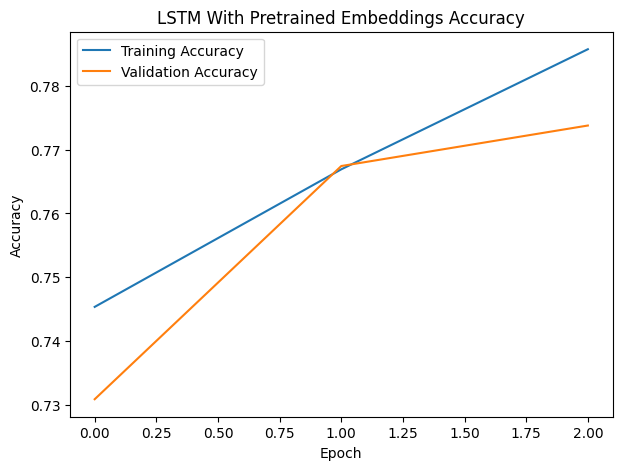

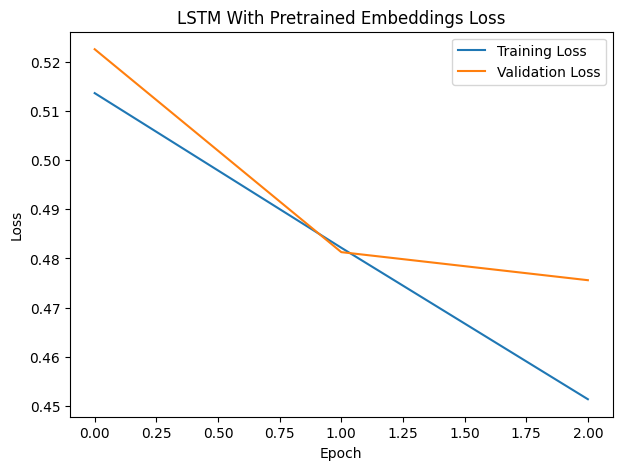

In [ ]:
plot_training_history(history_pretrained_lstm, "LSTM With Pretrained Embeddings")

179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
LSTM With Pretrained Embeddings Accuracy: 0.7302585604472397

Classification Report:
               precision    recall  f1-score   support

Not Sarcastic       0.69      0.89      0.78      2997
    Sarcastic       0.82      0.55      0.66      2727

     accuracy                           0.73      5724
    macro avg       0.75      0.72      0.72      5724
 weighted avg       0.75      0.73      0.72      5724



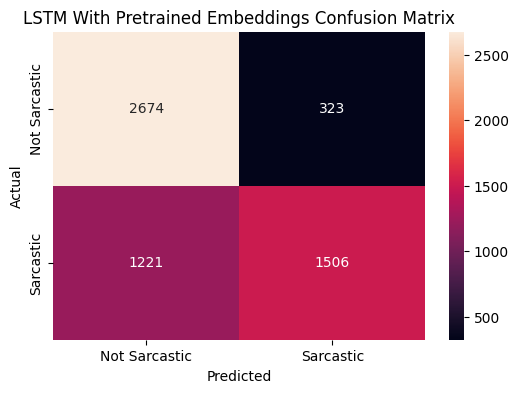

In [ ]:
pretrained_lstm_acc = evaluate_model(
    pretrained_lstm_model,
    X_test_pad,
    y_test,
    "LSTM With Pretrained Embeddings"
)

In [ ]:
results = pd.DataFrame({
    "Model": [
        "Simple RNN",
        "LSTM",
        "LSTM with Pretrained Embeddings"
    ],
    "Test Accuracy": [
        rnn_acc,
        lstm_acc,
        pretrained_lstm_acc
    ],
    "Training Time Seconds": [
        rnn_training_time,
        lstm_training_time,
        pretrained_lstm_training_time
    ]
})

results

,Model,Test Accuracy,Training Time Seconds
0,Simple RNN,0.780398,34.432012
1,LSTM,0.787212,30.631873
2,LSTM with Pretrained Embeddings,0.730259,16.124182


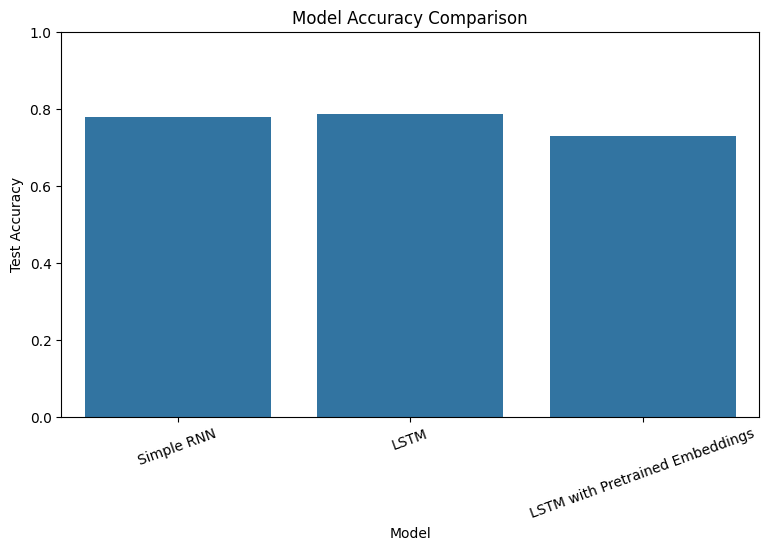

In [ ]:
plt.figure(figsize=(9,5))
sns.barplot(x="Model", y="Test Accuracy", data=results)
plt.title("Model Accuracy Comparison")
plt.ylim(0,1)
plt.xticks(rotation=20)
plt.show()

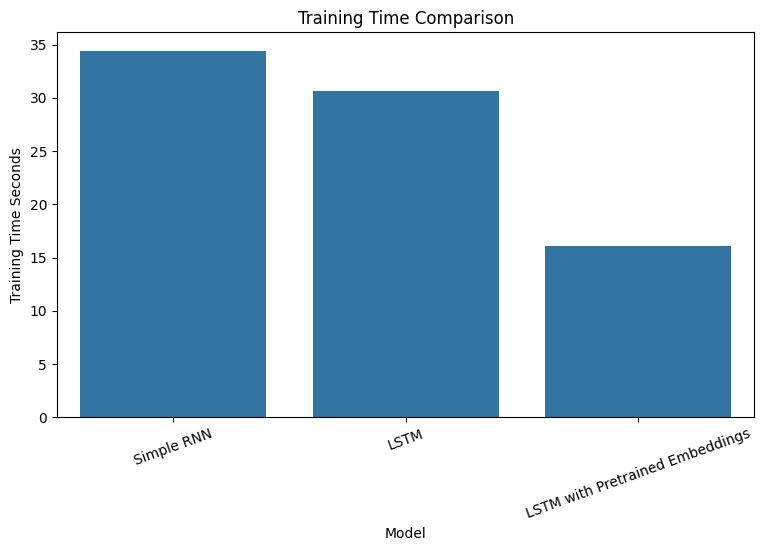

In [ ]:
plt.figure(figsize=(9,5))
sns.barplot(x="Model", y="Training Time Seconds", data=results)
plt.title("Training Time Comparison")
plt.xticks(rotation=20)
plt.show()

The three models were compared using accuracy, loss curves, confusion matrix, precision, recall, F1-score, and training time. The Simple RNN was used as the baseline recurrent model. The LSTM model was expected to perform better because it handles long-term dependencies more effectively. The pretrained embedding model was tested to evaluate whether external word representations improve classification performance.

In [ ]:
best_model = pretrained_lstm_model

y_pred_prob = best_model.predict(X_test_pad)
y_pred = (y_pred_prob > 0.5).astype("int32").flatten()

error_df = pd.DataFrame({
    "Original Headline": X_test.values,
    "Actual": y_test,
    "Predicted": y_pred,
    "Prediction Probability": y_pred_prob.flatten()
})

misclassified = error_df[error_df["Actual"] != error_df["Predicted"]]

misclassified.head(5)

179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


,Original Headline,Actual,Predicted,Prediction Probability
1,kris kobach defends using private email govern...,0,1,0.508836
4,democratic congressman protest trump environme...,1,0,0.163196
7,neither person conversation know hedge fund,1,0,0.302920
11,prayer answered random series event cold uncar...,1,0,0.187716
12,praise jesus big lebowski spinoff reportedly work,0,1,0.527561


In [ ]:
for i, row in misclassified.head(3).iterrows():
    print("Headline:", row["Original Headline"])
    print("Actual:", "Sarcastic" if row["Actual"] == 1 else "Not Sarcastic")
    print("Predicted:", "Sarcastic" if row["Predicted"] == 1 else "Not Sarcastic")
    print("Probability:", row["Prediction Probability"])
    print("-" * 80)

Headline: kris kobach defends using private email government business
Actual: Not Sarcastic
Predicted: Sarcastic
Probability: 0.5088362693786621
--------------------------------------------------------------------------------
Headline: democratic congressman protest trump environmental policy bringing endangered red wolf state union guest
Actual: Sarcastic
Predicted: Not Sarcastic
Probability: 0.1631961613893509
--------------------------------------------------------------------------------
Headline: neither person conversation know hedge fund
Actual: Sarcastic
Predicted: Not Sarcastic
Probability: 0.3029199540615082
--------------------------------------------------------------------------------


Some headlines were misclassified because sarcasm often depends on context, irony, cultural knowledge, or real-world background information. Short headlines may not contain enough textual clues for the model. In some cases, non-sarcastic headlines may contain unusual wording that resembles sarcasm, while sarcastic headlines may appear factual without additional context.

In [ ]:
def predict_sarcasm(text):
    cleaned = clean_text(text)
    sequence = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(
        sequence,
        maxlen=MAX_LEN,
        padding="post",
        truncating="post"
    )

    prediction = best_model.predict(padded)[0][0]

    if prediction >= 0.5:
        label = "Sarcastic"
    else:
        label = "Not Sarcastic"

    return f"Prediction: {label} | Confidence Score: {prediction:.4f}"

In [ ]:
predict_sarcasm("Scientists discover that sleeping during lectures improves exam performance")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step


'Prediction: Sarcastic | Confidence Score: 0.9557'

In [ ]:
interface = gr.Interface(
    fn=predict_sarcasm,
    inputs=gr.Textbox(lines=3, placeholder="Enter a headline here..."),
    outputs="text",
    title="Sarcastic Headline Classifier",
    description="Enter a news headline and the model will predict whether it is sarcastic or not."
)

interface.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://a041c73ac11d8825b7.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


This project presents a binary text classification system for detecting sarcasm in news headlines. The dataset contains headlines labelled as sarcastic or not sarcastic. The main objective was to preprocess textual data, convert headlines into numerical sequences, and compare recurrent neural network models for sarcasm classification. The text was cleaned by converting to lowercase, expanding contractions, removing URLs, numbers, special characters, stopwords, and applying lemmatization. Keras Tokenizer was used to convert words into integer sequences, followed by percentile-based padding. Three models were developed: a Simple RNN with trainable embedding, an LSTM with trainable embedding, and an LSTM using pretrained GloVe embeddings. The models were evaluated using accuracy, confusion matrix, precision, recall, and F1-score. The results showed that LSTM-based models were better suited for sequential text data compared to Simple RNN. The pretrained embedding model provided semantic word representations, although its performance depended on dataset vocabulary coverage. Error analysis showed that sarcasm is difficult to detect because it often requires context beyond the headline text.

Sarcasm detection is an important natural language processing task because sarcastic text often expresses the opposite of its literal meaning. This creates difficulty for sentiment analysis, opinion mining, social media monitoring, and automated content understanding. In this project, sarcastic headline classification was treated as a binary text classification problem. Recurrent neural networks were used because headlines are sequences of words, and word order can affect meaning. The project compares Simple RNN, LSTM, and LSTM with pretrained embeddings to analyze how different sequence models perform on sarcasm detection.

The dataset used in this project is a sarcastic headline dataset stored in CSV format. It contains news headlines and binary labels, where 1 represents sarcastic and 0 represents not sarcastic. The dataset was loaded using Pandas. Class distribution was analyzed to check whether the data was balanced. The headlines were cleaned and prepared before tokenization. The dataset was split into 80% training data and 20% testing data.

The methodology consisted of text preprocessing, tokenization, sequence padding, model building, training, and evaluation. Text cleaning included lowercasing, contraction expansion, URL removal, removal of mentions, hashtags, numbers, special characters, stopword removal, and lemmatization. The cleaned text was tokenized using Keras Tokenizer and padded using the 95th percentile sequence length. Three models were built: Simple RNN with trainable embeddings, LSTM with trainable embeddings, and LSTM with pretrained GloVe embeddings. Binary cross-entropy was used as the loss function because this is a binary classification task. Adam optimizer was used for training.

The Simple RNN model acted as the baseline sequence model. It was able to learn basic word patterns but may struggle with longer dependencies because traditional RNNs are affected by the vanishing gradient problem. The LSTM model improved this by using memory cells and gates, allowing it to retain useful information over longer sequences. The pretrained embedding model used GloVe vectors to provide semantic meaning before training. Model performance was compared using accuracy, precision, recall, F1-score, confusion matrix, and training time. The results helped evaluate the trade-off between model complexity and performance.

Misclassified headlines were analyzed to understand the model’s limitations. Some sarcastic headlines appeared factual, making them difficult to identify from text alone. Similarly, some non-sarcastic headlines contained unusual or humorous words that made them look sarcastic. These errors show that sarcasm detection often requires external context, tone, and background knowledge, which are not always available in short headlines.

This project successfully implemented sarcasm detection using RNN, LSTM, and pretrained embedding-based LSTM models. The LSTM models were more suitable than Simple RNN because they handled sequential information more effectively. Pretrained embeddings helped introduce external semantic knowledge, although their benefit depended on how well the dataset vocabulary matched the pretrained corpus. Future improvements could include using larger transformer-based models, increasing dataset size, tuning hyperparameters, and incorporating contextual information from article content.